In [1]:
import sys
import os

# Add the root path (2 levels up) to sys.path
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '..', '..')))

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from Autoencoder import Encoder, Decoder, AutoEncoder

### Use MNIST Dataset to visualize 

In [3]:
mnist_dataset = pd.read_csv('../../Convolutional_NeuralNetwork/train.csv')
mnist_dataset.head()

,label,pixel0,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,...,pixel774,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783
0,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,4,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [4]:
mnist_dataset.describe()

,label,pixel0,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,...,pixel774,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783
count,42000.000000,42000.0,42000.0,42000.0,42000.0,42000.0,42000.0,42000.0,42000.0,42000.0,...,42000.000000,42000.000000,42000.000000,42000.00000,42000.000000,42000.000000,42000.0,42000.0,42000.0,42000.0
mean,4.456643,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.219286,0.117095,0.059024,0.02019,0.017238,0.002857,0.0,0.0,0.0,0.0
std,2.887730,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,6.312890,4.633819,3.274488,1.75987,1.894498,0.414264,0.0,0.0,0.0,0.0
min,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.0,0.0,0.0,0.0
25%,2.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.0,0.0,0.0,0.0
50%,4.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.0,0.0,0.0,0.0
75%,7.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.0,0.0,0.0,0.0
max,9.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,254.000000,254.000000,253.000000,253.00000,254.000000,62.000000,0.0,0.0,0.0,0.0


##### Visualize sample

(-0.5, 27.5, 27.5, -0.5)

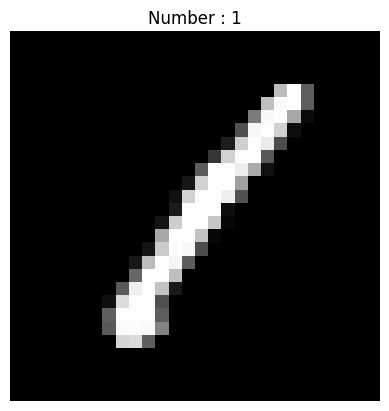

In [5]:
sample = mnist_dataset.iloc[0, 1:].to_numpy()
label = mnist_dataset.iloc[0, 0]
sample = sample.reshape(28, 28)
sample = sample/255.0

plt.imshow(sample, cmap='gray')
plt.title(label=f"Number : {label}")
plt.axis("off")

In [6]:
sample_ = sample.reshape(1, 28, 28, 1)

### Define encoder

In [7]:
encoder = Encoder(latent_dim=10)
encoded_image = encoder.forward(x=sample_)
encoded_image.shape

(10, 1)

In [8]:
count = 1
for i in encoder.encoder.forward_caches:
    output_shape = i['output'].shape
    print(f"output shape at layer {count} : {output_shape}")
    count += 1

output shape at layer 1 : (1, 28, 28, 1)
output shape at layer 2 : (1, 28, 28, 16)
output shape at layer 3 : (1, 14, 14, 16)
output shape at layer 4 : (1, 14, 14, 32)
output shape at layer 5 : (1, 7, 7, 32)
output shape at layer 6 : (1568, 1)
output shape at layer 7 : (10, 1)


(-0.5, 0.5, 9.5, -0.5)

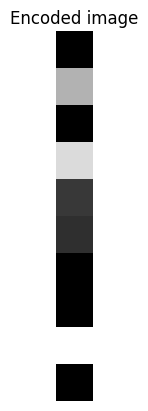

In [9]:
plt.imshow(encoded_image, cmap='gray')
plt.title("Encoded image")
plt.axis("off")

### Define Decoder

In [10]:
decoder = Decoder(latent_dim=10)
decoded_image = decoder.forward(encoded_image)

In [11]:
count = 1
for i in decoder.decoder.forward_caches:
    output_shape = i['output'].shape
    print(f"output shape at layer {count} : {output_shape}")
    count += 1

output shape at layer 1 : (10, 1)
output shape at layer 2 : (1568, 1)
output shape at layer 3 : (1, 7, 7, 32)
output shape at layer 4 : (1, 14, 14, 32)
output shape at layer 5 : (1, 14, 14, 16)
output shape at layer 6 : (1, 28, 28, 16)
output shape at layer 7 : (1, 28, 28, 1)


(-0.5, 27.5, 27.5, -0.5)

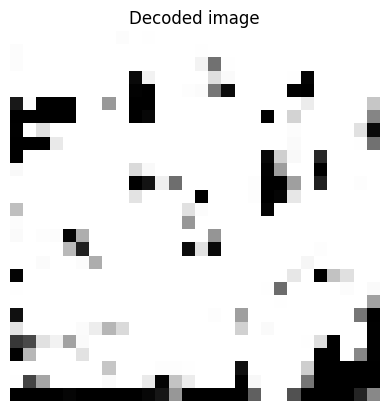

In [12]:
reshape_decoded_image = decoded_image.reshape((28, 28))
plt.imshow(reshape_decoded_image, cmap='gray')
plt.title("Decoded image")
plt.axis("off")

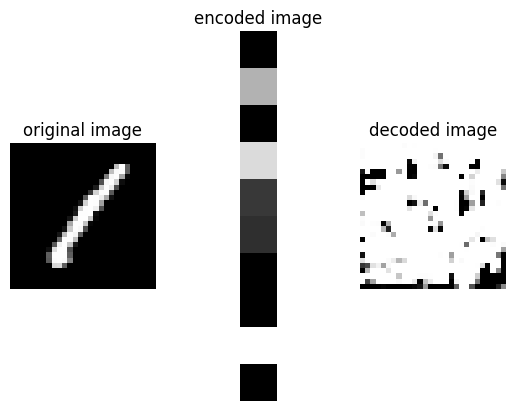

In [13]:
def plot_(origin_img, encoded_img, decoded_img):
    plt.Figure(figsize=(9, 5))
    plt.subplot(1, 3, 1)
    plt.imshow(origin_img, cmap='gray')
    plt.title("original image")
    plt.axis("off")
    
    plt.subplot(1, 3, 2)
    plt.imshow(encoded_img, cmap='gray')
    plt.title("encoded image")
    plt.axis("off")
    
    plt.subplot(1, 3, 3)
    plt.imshow(decoded_img, cmap='gray')
    plt.title("decoded image")
    plt.axis("off")
    
plot_(origin_img=sample, encoded_img=encoded_image, decoded_img=reshape_decoded_image)

### Test AutoEncoder

(-0.5, 27.5, 27.5, -0.5)

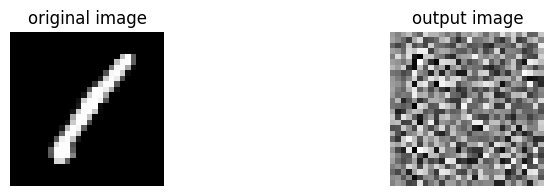

In [14]:
autoencoder_test = AutoEncoder(latent_dim=128, train_bias=True)
output = autoencoder_test.forward(sample_)
reshape_output = output.reshape((28, 28))
plt.figure(figsize=(9, 2))
plt.subplot(1, 2, 1)
plt.imshow(sample, cmap='gray')
plt.title("original image")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(reshape_output, cmap='gray')
plt.title("output image")
plt.axis("off")

##### Cache shape

In [15]:
### Forward 
for i in range(autoencoder_test.autoencoder.get_layer_length()):
    if autoencoder_test.autoencoder._layers[i].weights is not None:
        print(f"Layer {i + 1} weights shape : {autoencoder_test.autoencoder._layers[i].weights.shape}")
    else : 
        print(f"Layer {i + 1} has no weights")

Layer 1 weights shape : (16, 3, 3, 1)
Layer 2 weights shape : (1, 1, 1, 16)
Layer 3 has no weights
Layer 4 weights shape : (32, 3, 3, 16)
Layer 5 weights shape : (1, 1, 1, 32)
Layer 6 has no weights
Layer 7 has no weights
Layer 8 weights shape : (1568, 128)
Layer 9 weights shape : (128, 1568)
Layer 10 has no weights
Layer 11 weights shape : (16, 3, 3, 32)
Layer 12 weights shape : (1, 1, 1, 16)
Layer 13 weights shape : (8, 3, 3, 16)
Layer 14 weights shape : (1, 1, 1, 8)
Layer 15 weights shape : (1, 3, 3, 8)


In [16]:
autoencoder_test.backward(gradient_loss=output-sample)
for i in range(autoencoder_test.autoencoder.get_layer_length()):
    if autoencoder_test.autoencoder._layers[i].weights is not None:
        print(f"Layer {i + 1} d_weights shape : {autoencoder_test.autoencoder.backward_caches[i]['dW'].shape}")
    else : 
        print(f"Layer {i + 1} has no weights")

Layer 1 d_weights shape : (16, 3, 3, 1)
Layer 2 d_weights shape : (1, 1, 1, 16)
Layer 3 has no weights
Layer 4 d_weights shape : (32, 3, 3, 16)
Layer 5 d_weights shape : (1, 1, 1, 32)
Layer 6 has no weights
Layer 7 has no weights
Layer 8 d_weights shape : (1568, 128)
Layer 9 d_weights shape : (128, 1568)
Layer 10 has no weights
Layer 11 d_weights shape : (16, 3, 3, 32)
Layer 12 d_weights shape : (1, 1, 1, 16)
Layer 13 d_weights shape : (8, 3, 3, 16)
Layer 14 d_weights shape : (1, 1, 1, 8)
Layer 15 d_weights shape : (1, 3, 3, 8)


### Train autoencoder

##### Train Test split

In [17]:
x = mnist_dataset.iloc[:, 1:]
y = mnist_dataset.iloc[:, 0]
x.shape

(42000, 784)

In [18]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=.2)
x_train.shape, x_test.shape

((33600, 784), (8400, 784))

##### Normalize 

In [19]:
x_train = x_train.astype(np.float32) / 255.
x_test = x_test.astype(np.float32) / 255.

##### Train

In [20]:
autoencoder = AutoEncoder(latent_dim=128, optimizer='adam', metric='bce', train_bias=True)
autoencoder.fit(x_train=x_train, epochs=16, learning_rate=0.0005, batch_size=128, loss_per_epochs=2, regularization='l2', lambda_reg=0.0001, check_point=True)

Epochs:  12%|█▎        | 2/16 [03:41<25:46, 110.43s/it, Loss=0.5991]

Model parameters is saved to model/check_points\checkpoint_epochs_2_weights.npz
Model parameters is saved to model/check_points\checkpoint_epochs_2_weights.npz


Epochs:  25%|██▌       | 4/16 [07:23<22:10, 110.87s/it, Loss=0.5750]

Model parameters is saved to model/check_points\checkpoint_epochs_4_weights.npz
Model parameters is saved to model/check_points\checkpoint_epochs_4_weights.npz


Epochs:  38%|███▊      | 6/16 [13:41<26:18, 157.85s/it, Loss=0.7130]

...

Model parameters is saved to model/check_points\checkpoint_epochs_12_weights.npz
Model parameters is saved to model/check_points\checkpoint_epochs_12_weights.npz


Epochs:  88%|████████▊ | 14/16 [30:40<04:01, 120.66s/it, Loss=1.0035]

Model parameters is saved to model/check_points\checkpoint_epochs_14_weights.npz
Model parameters is saved to model/check_points\checkpoint_epochs_14_weights.npz


Epochs: 100%|██████████| 16/16 [34:32<00:00, 129.54s/it, Loss=0.5245]

Model parameters is saved to model/check_points\checkpoint_epochs_16_weights.npz
Model parameters is saved to model/check_points\checkpoint_epochs_16_weights.npz


##### Loss

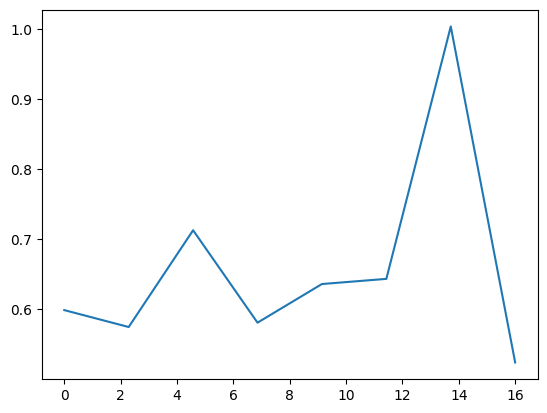

In [21]:
loss_curve = np.array(autoencoder.loss_curve)
if autoencoder.epochs // autoencoder.loss_per_epochs == 1:
    print(loss_curve[0])
else:
    epochs = np.linspace(0, autoencoder.epochs, num=autoencoder.epochs//autoencoder.loss_per_epochs)
    plt.plot(epochs, loss_curve)

##### Test sample

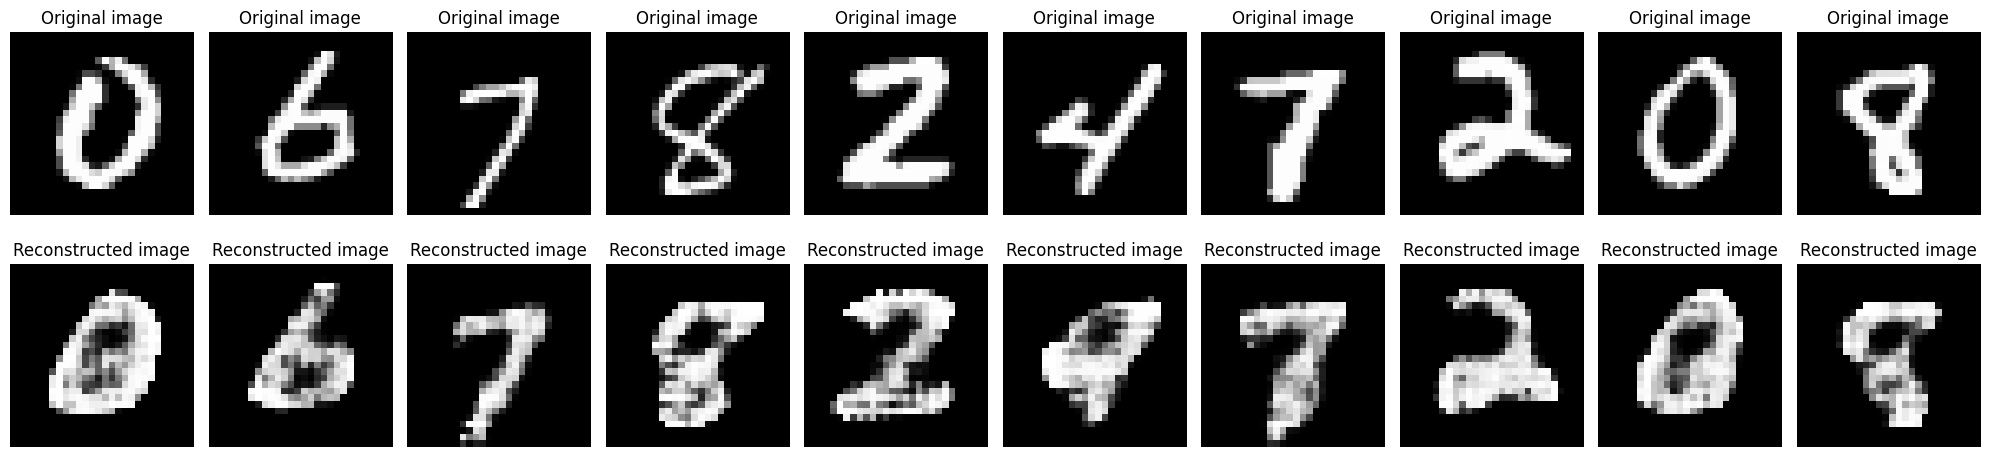

In [22]:
def plot_sample(num_sample=10):
    plt.figure(figsize=(20, 5))
    random_idx = np.random.choice(x_train.shape[0], size=num_sample, replace=False)
    outputs = []
    origins = []
    for idx in random_idx:
        xi = x_train.iloc[idx, :].to_numpy().reshape(1, 28, 28, 1)
        origins.append(xi.reshape((28, 28)))
        output = autoencoder.predict(xi)
        outputs.append(output.reshape((28, 28)))
    for i in range(num_sample):
        ax = plt.subplot(2, num_sample, i + 1)
        plt.title("Original image")
        plt.imshow(origins[i], cmap='gray')
        plt.axis("off")
        
        ax = plt.subplot(2, num_sample, i + 1 + num_sample)
        plt.title("Reconstructed image")
        plt.imshow(outputs[i], cmap='gray')
        plt.axis("off")
        
    plt.tight_layout()
    plt.show()
        
plot_sample(10)

##### Save model

In [23]:
autoencoder.save_model()

Model parameters is saved to model/parameters\model_weights.npz
